In [ ]:
import torch
print(torch.__version__)

2.8.0+cu126


In [ ]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available: 1


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from transformers import DistilBertTokenizerFast, TFDistilBertModel
from tensorflow.keras.layers import Input, Lambda, Bidirectional, LSTM, Dense
from tensorflow.keras.models import Model
import re
import zipfile
import os

In [ ]:
import pandas as pd
import numpy as np
import re
import tensorflow as tf
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizerFast, TFDistilBertModel
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional
from tensorflow.keras.models import Model


In [ ]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available: 1


1. Mount Drive and extract dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

# List contents of your Drive root or a subfolder
os.listdir('/content/drive/MyDrive/')


['Classroom',
 'CS22B2018 .pdf',
 'CS22B2018',
 'CS22B2018 (1).pdf',
 'PDFGallery_20221129_181625.pdf',
 'leaf activity CS22B2018.pdf',
 'assignment 1 .. vector and fields.pdf',
 'ASSIGNMENT 1 PHY.pdf',
 'Document from Gayathri.pdf',
 'CS22B2018.. assignment1..pdf',
 'grssd.pdf',
 'system flow chart (1).jpg',
 'system flow chart.jpg',
 'composition with leaves',
 'IMG_20230122_185321.jpg',
 'IMG_20230122_185648.jpg',
 'composition with leaves.pdf',
 'PDFGallery_20230128_214808.pdf',
 '06 Differentiation (1).gdoc',
 '06 Differentiation.gdoc',
 'photo ',
 '16801000109433245265743819058907.jpg',
 'Old Pension Scheme Order.pdf',
 'ATC camp May 2023 approval letter.pdf',
 'report .pdf',
 'DSC assignment .pdf',
 'report 2.pdf',
 'cs22b2018.pdf',
 'ATC camp May 2023 approval letter_copy.pdf',
 'os.pdf',
 'application.cpp',
 'stack.file',
 'application.file',
 'CS22B2018.pdf',
 'lab2.file',
 'program 7.pdf',
 'program 6',
 'program 5.pdf',
 'program 4',
 'program 1.pdf',
 'program 2.pdf',
 'pr

In [ ]:
zip_path = '/content/drive/MyDrive/fakenews_dataset/fakenew_dataset.zip'


In [ ]:
import os

os.listdir('/content/drive/MyDrive/fakenews_dataset')



['News-_dataset.zip']

In [ ]:
zip_path = '/content/drive/MyDrive/fakenews_dataset/News-_dataset.zip'
extract_to = '/content/dataset'

import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)


In [ ]:
import os
os.listdir('/content/dataset')


['Fake.csv', 'True.csv']

# 2. Load and label the data

In [ ]:
import pandas as pd

# Load each file
true_df = pd.read_csv('/content/dataset/True.csv')
fake_df = pd.read_csv('/content/dataset/Fake.csv')

# Add labels
true_df['label'] = 1
fake_df['label'] = 0

# Combine both
df = pd.concat([true_df, fake_df], ignore_index=True)

# Shuffle the combined dataset (optional but useful before training)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


 3. Clean the text

In [ ]:
df.head()
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r'[^A-Za-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text'] = df['text'].astype(str).apply(clean_text)
df = df[df['text'].str.len() > 20].reset_index(drop=True)
texts = (df['title'] + " " + df['text']).astype(str).fillna('').tolist()
labels = df['label'].tolist()
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
encodings = tokenizer(texts, truncation=True, padding='max_length', max_length=512, return_tensors='tf')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


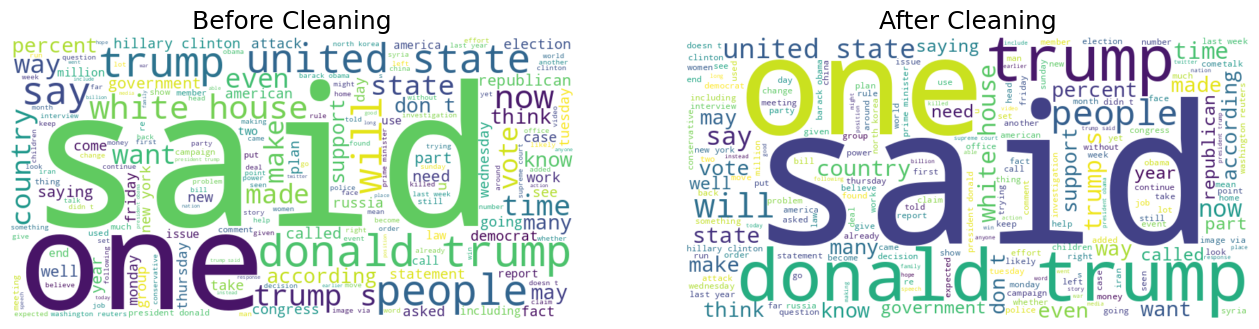

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Before cleaning
text_raw = " ".join(df['text'].astype(str).tolist())
wordcloud_raw = WordCloud(width=800, height=400, background_color='white').generate(text_raw)

# After cleaning
df['clean_text'] = df['text'].astype(str).apply(clean_text)
text_cleaned = " ".join(df['clean_text'].tolist())
wordcloud_cleaned = WordCloud(width=800, height=400, background_color='white').generate(text_cleaned)

# Plot side by side
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_raw, interpolation='bilinear')
plt.title('Before Cleaning', fontsize=18)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_cleaned, interpolation='bilinear')
plt.title('After Cleaning', fontsize=18)
plt.axis('off')
plt.show()


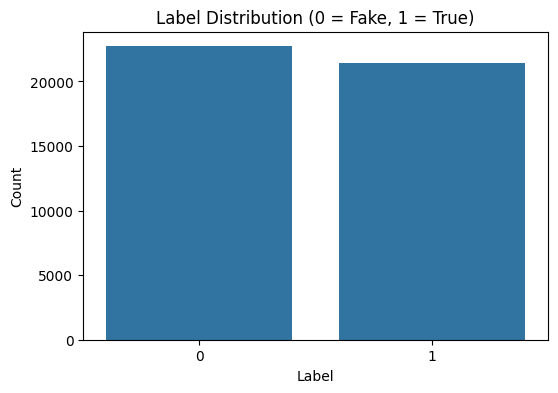

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Label Distribution (0 = Fake, 1 = True)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


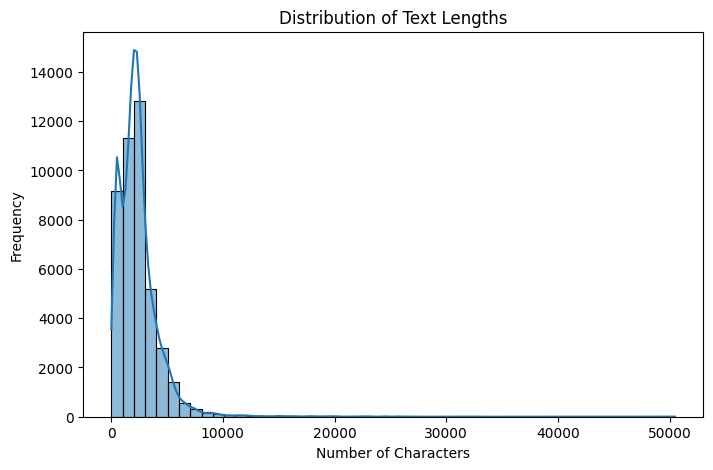

In [ ]:
df['text_length'] = df['clean_text'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title("Distribution of Text Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()


In [ ]:
input_ids = encodings['input_ids']
attention_mask = encodings['attention_mask']
import numpy as np
from sklearn.model_selection import train_test_split

# Convert to numpy
input_ids_np = input_ids.numpy()
attention_mask_np = attention_mask.numpy()
labels_np = np.array(labels)


In [ ]:
# Split into train and validation sets
train_input_ids, val_input_ids, train_attention_mask, val_attention_mask, y_train, y_val = train_test_split(
    input_ids_np, attention_mask_np, labels_np, test_size=0.2, random_state=42
)

7. Build model

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, Lambda
from tensorflow.keras.models import Model
from transformers import TFDistilBertModel

# ======================
# Load DistilBERT
# ======================
# Add from_pt=True to fix the safe_open error
bert_model = TFDistilBertModel.from_pretrained("distilbert-base-uncased", from_pt=True)

# ======================
# Define Inputs
# ======================
input_ids = Input(shape=(512,), dtype=tf.int32, name="input_ids")
attention_mask = Input(shape=(512,), dtype=tf.int32, name="attention_mask")

# ======================
# Wrap DistilBERT inside Lambda (your original way)
# ======================
def distilbert_layer(inputs):
    # inputs is a list: [input_ids, attention_mask]
    return bert_model(inputs)[0]   # last_hidden_state

bert_output = Lambda(distilbert_layer, output_shape=(512, 768))([input_ids, attention_mask])

# ======================
# LSTM + Dense layers
# ======================
lstm_out = Bidirectional(LSTM(64))(bert_output)
dense = Dense(64, activation='relu')(lstm_out)
output = Dense(1, activation='sigmoid')(dense)

# ======================
# Build Model
# ======================
model = Model(inputs=[input_ids, attention_mask], outputs=output)

model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision')]
)

# ======================
# Summary
# ======================
model.summary()


pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.bias', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_projector.weight', 'vocab_layer_norm.weight', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 512, 768)  │          0 │ input_ids[0][0],  │
│                     │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │    426,496 │ lambda[0][0]      │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 434,817 (1.66 MB)

 Trainable params: 434,817 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

8. Train model

In [ ]:
history = model.fit(
    [train_input_ids, train_attention_mask],
    np.array(y_train),
    validation_data=([val_input_ids, val_attention_mask], np.array(y_val)),
    epochs=3,
    batch_size=8
)

Epoch 1/3
4414/4414 ━━━━━━━━━━━━━━━━━━━━ 1033s 232ms/step - accuracy: 0.9063 - auc: 0.9600 - loss: 0.2483 - precision: 0.9226 - val_accuracy: 0.9877 - val_auc: 0.9988 - val_loss: 0.0406 - val_precision: 0.9926
Epoch 2/3
4414/4414 ━━━━━━━━━━━━━━━━━━━━ 1050s 234ms/step - accuracy: 0.9906 - auc: 0.9993 - loss: 0.0305 - precision: 0.9897 - val_accuracy: 0.9932 - val_auc: 0.9994 - val_loss: 0.0220 - val_precision: 0.9953
Epoch 3/3
4414/4414 ━━━━━━━━━━━━━━━━━━━━ 1034s 234ms/step - accuracy: 0.9943 - auc: 0.9997 - loss: 0.0176 - precision: 0.9940 - val_accuracy: 0.9949 - val_auc: 0.9994 - val_loss: 0.0173 - val_precision: 0.9965


In [ ]:
from sklearn.model_selection import train_test_split

# Suppose your dataset is in X, y
# First split into train+temp and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


NameError: name 'X' is not defined

In [ ]:
from sklearn.metrics import roc_curve
import numpy as np

# Get predicted probabilities
y_pred_proba = model.predict(X_test).ravel()

# Compute FPR and TPR
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Compute FNR
fnr = 1 - tpr

# Compute Equal Error Rate (EER)
eer_threshold = thresholds[np.nanargmin(np.absolute((fnr - fpr)))]
eer = fpr[np.nanargmin(np.absolute((fnr - fpr)))]

# Now plot EER
plt.figure(figsize=(6,6))
plt.plot(fpr, fnr, label='FNR vs FPR')
plt.plot(eer, eer, 'ro', label=f'EER = {eer:.4f}')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('False Negative Rate (FNR)')
plt.title('Equal Error Rate (EER)')
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'X_test' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 1: Predict Probabilities
y_pred_probs = model.predict([X_val_ids, X_val_mask], batch_size=16)
y_pred = (y_pred_probs > 0.5).astype(int)

# Step 2: Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Step 3: ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend()
plt.grid(True)
plt.show()

# Step 4: Equal Error Rate (EER)
fnr = 1 - tpr
eer_threshold_index = np.nanargmin(np.absolute(fnr - fpr))
eer = fpr[eer_threshold_index]
print(f"Equal Error Rate (EER): {eer:.4f}")

# Step 5: Optional Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, y_pred, target_names=['Fake', 'Real']))


NameError: name 'X_val_ids' is not defined

In [ ]:
model.save('my_model.keras')  # recommended format


In [ ]:
new_text = ["Breaking news: Government launches new AI initiative"]


In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r'[^A-Za-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

cleaned = [clean_text(t) for t in new_text]


In [ ]:
from transformers import DistilBertTokenizerFast
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

enc = tokenizer(cleaned, truncation=True, padding='max_length', max_length=512, return_tensors='tf')


In [ ]:
pred = model.predict([enc['input_ids'], enc['attention_mask']])
print(f"Prediction: {pred[0][0]:.4f}")

# Optional: interpret as label
label = 'Real' if pred[0][0] >= 0.5 else 'Fake'
print(f"Predicted Label: {label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: 0.9717
Predicted Label: Real


In [ ]:
test_text = "Donald Trump wins the 2024 elections unexpectedly, shocking global analysts."


In [ ]:
cleaned_text = clean_text(test_text)


In [ ]:
test_input = tokenizer(cleaned_text, truncation=True, padding='max_length', max_length=512, return_tensors='tf')


In [ ]:
prediction = model.predict([test_input['input_ids'], test_input['attention_mask']])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


In [ ]:
if prediction[0][0] >= 0.5:
    print("✅ Real News (Label 1)")
else:
    print("❌ Fake News (Label 0)")

print(f"Confidence Score: {prediction[0][0]:.4f}")


✅ Real News (Label 1)
Confidence Score: 0.6470
